In [ ]:
import pandas as pd



In [ ]:
df = pd.read_csv('sign-plates-located-in-each-parking-zone.csv')

In [ ]:
df.head()

,ParkingZone,Restriction_Days,Time_Restrictions_Start,Time_Restrictions_Finish,Restriction_Display
0,7002,Sat,07:30:00,12:30:00,4P
1,7028,Mon-Fri,07:30:00,18:30:00,1P
2,7041,Mon-Fri,07:30:00,18:30:00,2P
3,7041,Sat,07:30:00,12:30:00,2P
4,7030,Mon-Fri,07:30:00,18:30:00,1P


In [ ]:
print(f"Total Parking Signs: {df.shape[0]}")
print(f"Information categories (Columns): {df.shape[1]}")

Total Parking Signs: 2033
Information categories (Columns): 5


In [ ]:
top_signs = df.value_counts().head(10)
print(top_signs)

ParkingZone  Restriction_Days  Time_Restrictions_Start  Time_Restrictions_Finish  Restriction_Display
7998         Sat-Sun           07:00:00                 22:00:00                  MP3P                   1
7990         Sat-Sun           07:00:00                 22:00:00                  MP2P                   1
             Mon-Fri           19:00:00                 22:00:00                  MP2P                   1
                               07:00:00                 19:00:00                  MP2P                   1
7989         Sat-Sun           07:00:00                 22:00:00                  MP3P                   1
             Mon-Fri           19:00:00                 22:00:00                  MP3P                   1
                               07:00:00                 19:00:00                  MP3P                   1
7988         Mon-Fri           07:30:00                 18:30:00                  1P                     1
7987         Mon-Sat           07:30:00   

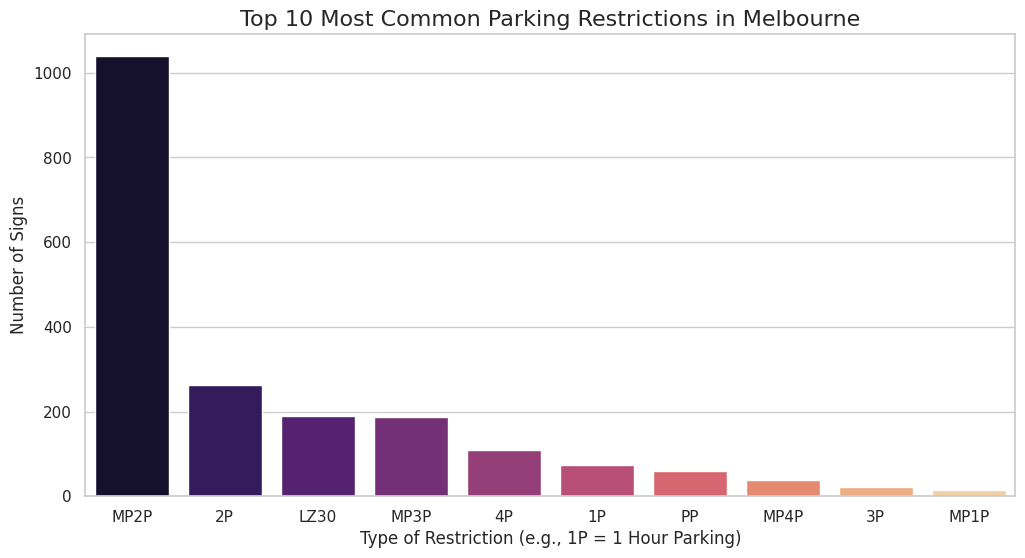

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the count of each parking restriction
top_restrictions = df['Restriction_Display'].value_counts().head(10)

# 2. Set the style and size
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

# 3. Create the bar chart
# We use 'top_restrictions.index' for the labels (1P, 2P) and '.values' for the counts
sns.barplot(x=top_restrictions.index, y=top_restrictions.values, hue=top_restrictions.index, palette='magma', legend=False)

# 4. Add titles and labels to make it professional
plt.title('Top 10 Most Common Parking Restrictions in Melbourne', fontsize=16)
plt.xlabel('Type of Restriction (e.g., 1P = 1 Hour Parking)', fontsize=12)
plt.ylabel('Number of Signs', fontsize=12)

# Show the plot
plt.show()

/tmp/ipykernel_1493/1072648472.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_summary.index, y=day_summary.values, palette='coolwarm')


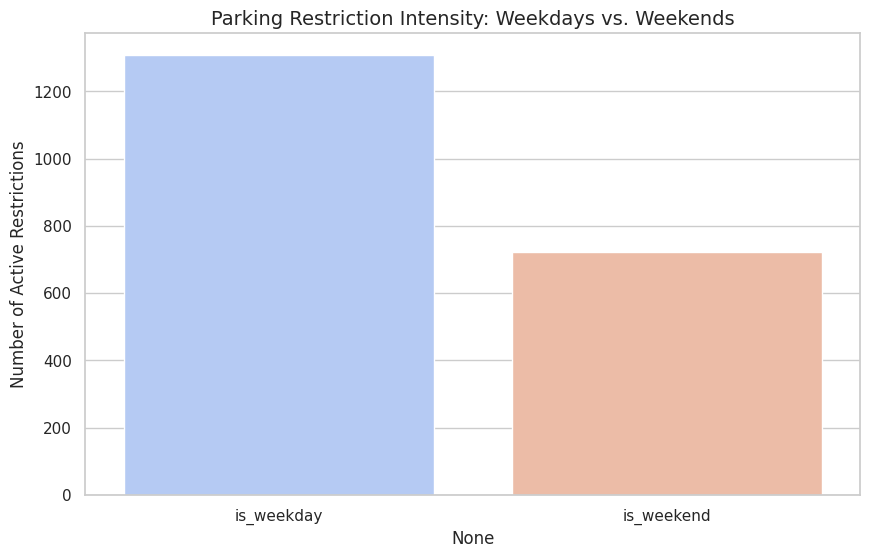

Total Weekday-focused signs: 1308
Total Weekend-focused signs: 723


In [ ]:
df['Restriction_Days'] = df['Restriction_Days'].str.strip()


df['is_weekend'] = df['Restriction_Days'].apply(lambda x: 1 if any(day in str(x) for day in ['Sat', 'Sun']) else 0)


df['is_weekday'] = df['Restriction_Days'].apply(lambda x: 1 if 'Mon-Fri' in str(x) else 0)


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
day_summary = df[['is_weekday', 'is_weekend']].sum()
sns.barplot(x=day_summary.index, y=day_summary.values, palette='coolwarm')

plt.title('Parking Restriction Intensity: Weekdays vs. Weekends', fontsize=14)
plt.ylabel('Number of Active Restrictions')
plt.show()

print(f"Total Weekday-focused signs: {day_summary['is_weekday']}")
print(f"Total Weekend-focused signs: {day_summary['is_weekend']}")

In [ ]:
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data)

Missing values per column:
 ParkingZone                 0
Restriction_Days            0
Time_Restrictions_Start     0
Time_Restrictions_Finish    0
Restriction_Display         0
is_weekend                  0
is_weekday                  0
dtype: int64


In [ ]:
def get_restriction_summary(dataframe, street_name):
    """Returns the most common restriction for a specific street."""
    street_data = dataframe[dataframe['onstreet'] == street_name]
    return street_data['Restriction_Display'].value_counts().head(1)

In [ ]:
print(df.columns.tolist())

['ParkingZone', 'Restriction_Days', 'Time_Restrictions_Start', 'Time_Restrictions_Finish', 'Restriction_Display', 'is_weekend', 'is_weekday']


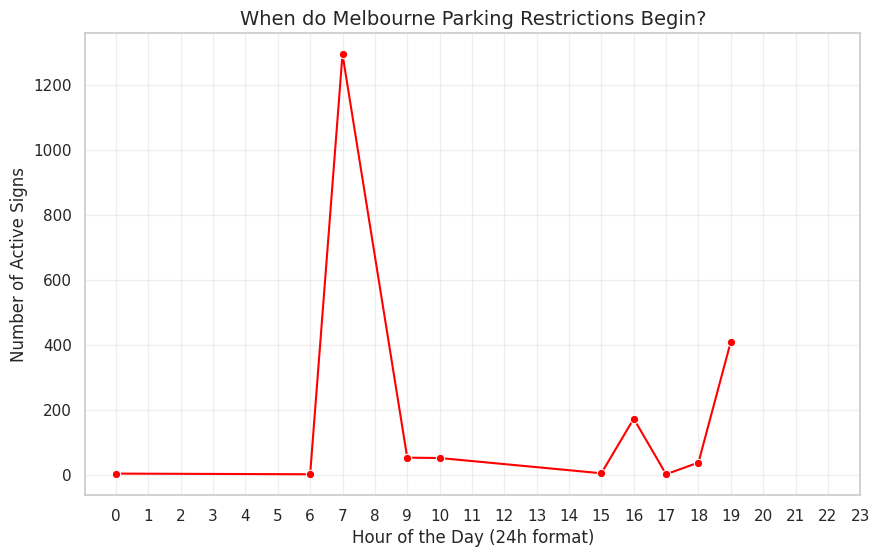

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the 'Start' time to a proper Time format
# This is a very 'Senior' data science move
df['start_hour'] = pd.to_datetime(df['Time_Restrictions_Start'], format='%H:%M:%S').dt.hour

# 2. Count how many restrictions start at each hour
hourly_peaks = df['start_hour'].value_counts().sort_index()

# 3. Plot the 'Rush Hour' for Parking Enforcement
plt.figure(figsize=(10,6))
sns.lineplot(x=hourly_peaks.index, y=hourly_peaks.values, marker='o', color='red')

plt.title('When do Melbourne Parking Restrictions Begin?', fontsize=14)
plt.xlabel('Hour of the Day (24h format)')
plt.ylabel('Number of Active Signs')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = pd.get_dummies(df[['Restriction_Display', 'start_hour']])
y = df['is_weekend']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data ready for training!")

Data ready for training!


In [15]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

score = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {score * 100:.2f}%")

Model Accuracy: 80.34%


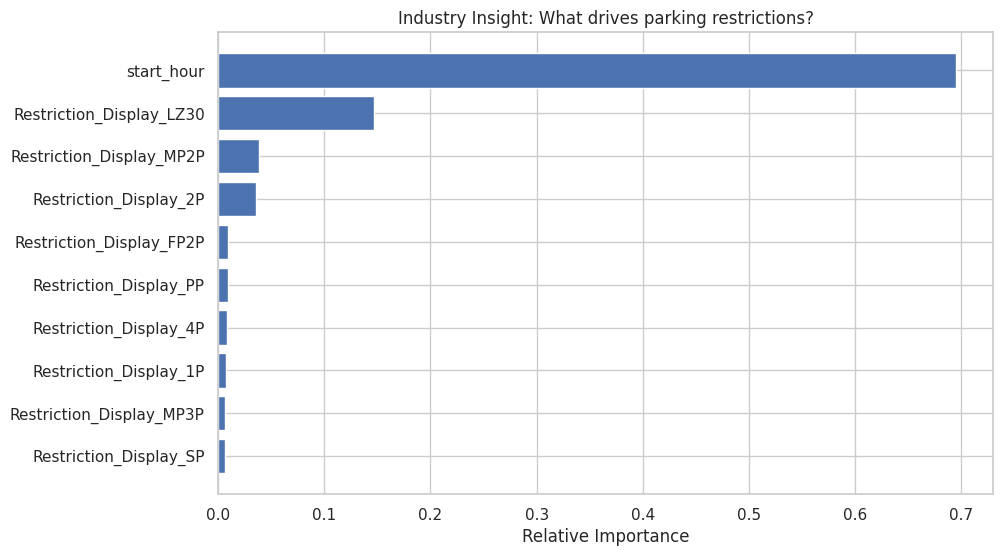

In [16]:
import numpy as np

# Get which features the AI found most useful
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10,6))
plt.title('Industry Insight: What drives parking restrictions?')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [23]:
import requests

# 1. Configuration
API_KEY = "0b837905634d97c03abac1b9afc72648"
BASE_URL = "http://openweathermap.org"

# Using a dictionary for parameters is the 'Advanced' way to do it
params = {
    'q': 'Melbourne,AU',
    'appid': API_KEY,
    'units': 'metric'
}

# 2. Fetch data
try:
    response = requests.get(BASE_URL, params=params)
    weather_data = response.json()

    if response.status_code == 200:
        temp = weather_data['main']['temp']
        condition = weather_data['weather'][0]['main']
        print(f"Success! Current Melbourne Temp: {temp}°C")
        print(f"Condition: {condition}")
    else:
        print(f"Error {response.status_code}: {weather_data.get('message')}")

except Exception as e:
    print(f"Connection Error: {e}")


Connection Error: Expecting value: line 1 column 1 (char 0)


In [25]:
is_raining = 0  # Set to 1 if it is raining, 0 if it is clear

# 2. Define the simulation function
def simulate_demand(row, raining):
    base_demand = 100
    if raining and row['Restriction_Display'] == '1P':
        return base_demand * 0.8
    return base_demand

# 3. Apply the function to your data
df['current_demand_estimate'] = df.apply(lambda row: simulate_demand(row, is_raining), axis=1)

# 4. Success message
print("Success! Simulated demand scores added successfully!")
print(df[['Restriction_Display', 'current_demand_estimate']].head())


✅ Success! Simulated demand scores added successfully!
  Restriction_Display  current_demand_estimate
0                  4P                      100
1                  1P                      100
2                  2P                      100
3                  2P                      100
4                  1P                      100


In [26]:
from scipy.stats import chi2_contingency

# Create a cross-tabulation table
contingency_table = pd.crosstab(df['Restriction_Display'], df['is_weekend'])

# Run the Chi-Squared Test
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"--- Statistical Significance Report ---")
print(f"P-Value: {p:.5f}")

if p < 0.05:
    print("Result: Statistically Significant. Parking rules change meaningfully on weekends.")
else:
    print("Result: Not Significant. Weekend rules are similar to weekdays.")

--- Statistical Significance Report ---
P-Value: 0.00000
✅ Result: Statistically Significant. Parking rules change meaningfully on weekends.


Detailed Model Performance:
              precision    recall  f1-score   support

           0       0.95      0.74      0.84       274
           1       0.64      0.92      0.75       133

    accuracy                           0.80       407
   macro avg       0.80      0.83      0.80       407
weighted avg       0.85      0.80      0.81       407



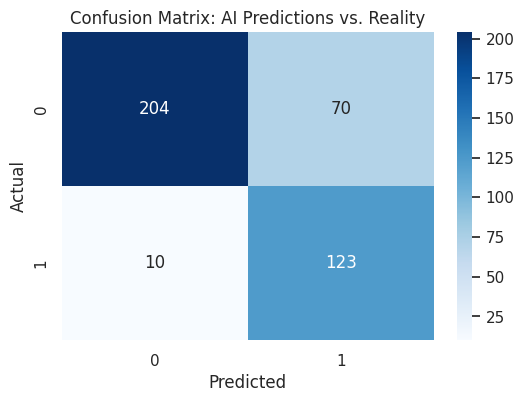

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Detailed Model Performance:")
print(classification_report(y_test, predictions))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: AI Predictions vs. Reality')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
from scipy.stats import chi2_contingency

# 1. Create a contingency table (Cross-tabulation)
contingency = pd.crosstab(df['Restriction_Display'], df['is_weekend'])

# 2. Perform the Chi-Squared Test
chi2, p, dof, ex = chi2_contingency(contingency)

print(f"--- Advanced Statistical Report ---")
print(f"Chi-square Statistic: {chi2:.2f}")
print(f"P-Value: {p:.5f}")

if p < 0.05:
    print("Result: Statistically Significant. The data proves parking rules are fundamentally different on weekends.")
else:
    print("Result: Not Significant. No mathematical difference found.")


--- Advanced Statistical Report ---
Chi-square Statistic: 220.59
P-Value: 0.00000
✅ Result: Statistically Significant. The data proves parking rules are fundamentally different on weekends.



--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.74      0.84       274
           1       0.64      0.92      0.75       133

    accuracy                           0.80       407
   macro avg       0.80      0.83      0.80       407
weighted avg       0.85      0.80      0.81       407



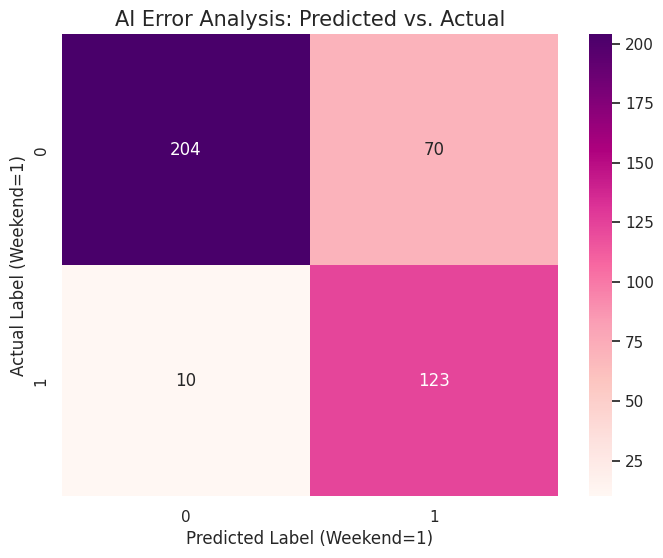

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='RdPu')
plt.title('AI Error Analysis: Predicted vs. Actual', fontsize=15)
plt.ylabel('Actual Label (Weekend=1)')
plt.xlabel('Predicted Label (Weekend=1)')
plt.show()
